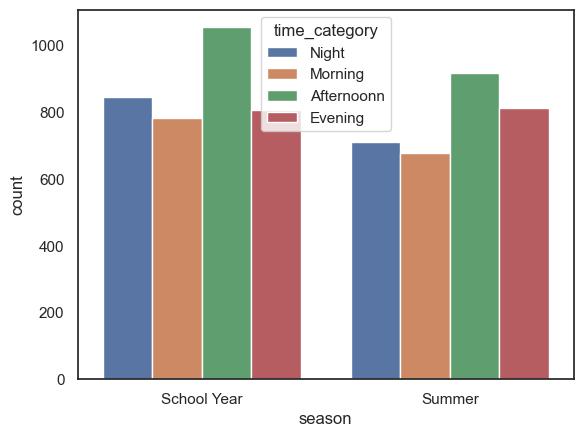

In [56]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

crime = pd.read_csv("cleaned_data_feature_engineered_v1.csv")

crime['occurrence_time'] = crime['occurrence_time'].astype(str).str.replace(':','')

crime['occurrence_time'] = pd.to_datetime(crime['occurrence_time'], format = '%H%M')

crime['hour'] = crime['occurrence_time'].dt.hour

crime['time_category'] = pd.cut(
    crime['hour'],
    bins = [0, 6, 12, 18, 24], 
    labels = ["Night", "Morning", "Afternoonn", "Evening"],
    right = False
)

school_calendar = { 
    2020: ("2020-09-30", "2021-06-10"),
    2021: ("2021-09-22", "2022-06-09"),
    2022: ("2022-09-21", "2023-06-15"),
    2023: ("2023-09-27", "2024-06-13"),
    2024: ("2024-09-25", "2025-06-12")
}

crime['occurrence_date'] = pd.to_datetime(crime['occurrence_date'])

def school(date):
    for year, (start, end) in school_calendar.items():
        
        start = pd.Timestamp(start)
        end = pd.Timestamp(end)

        if start <= date <= end:
            return "School Year"

    return "Summer"

crime['season'] = crime['occurrence_date'].apply(school)
                                          
p = sns.countplot(x = "season", hue = "time_category", data = crime)
plt.show() 

#count plot for number of crimes occurring at certain time of the day and categorizing if they occurred during the school year or summer time.

In [42]:
crime.head(5)

,case_number,report_date,occurrence_date,occurrence_time,offense_description,incident_number,place,city,disposition,beat,...,y_coord,block_number,street,coord_check,upload_date,crime_type,crime_classification,hour,time_category,season
0,24-04377,2024-10-21,2020-10-21,1900-01-01 22:00:00,Battery on person - Simple (M),202410210178,NaN,Davis,NaN,2,...,38.545210,0,4TH ST/C ST,Y,2025-04-23,Assault,Misdemeanor,22,Evening,School Year
1,22-05316,2022-11-28,2021-01-01,1900-01-01 00:00:00,Grand theft:money/labor/property - Motor vehic...,202211280021,NaN,Davis,NaN,1,...,38.562660,2200,FORTUNA CT,Y,2026-01-30,Larceny/Theft,Felony,0,Night,School Year
2,21-05281,2021-12-12,2021-03-16,1900-01-01 00:00:00,Stalking (F),202112120047,PACIFICO COOPERATIVE COMMUNITY,Davis,NaN,4,...,38.537979,1700,DREW CI,Y,2025-01-23,Assault,Felony,0,Night,School Year
3,21-01994,2021-05-17,2021-03-18,1900-01-01 12:07:00,Contact minor with intent sex (F); Annoy/moles...,202105170050,HOLMES JUNIOR HIGH SCHOOL,Davis,C,2,...,38.557056,1200,DREXEL DR,Y,2025-03-25,All Other Offenses,Felony,12,Afternoonn,School Year
4,21-04680,2021-11-05,2021-05-01,1900-01-01 00:00:00,Rape by force/fear/etc - Rape (F); Mandated Re...,202111050086,DAVIS HIGH SCHOOL,Davis,E,2,...,38.555664,300,W 14TH ST,Y,2025-09-05,Sex Offenses-Forcible,Felony,0,Night,School Year


In [54]:
import pandas as pd
import numpy as np

df = pd.read_csv("cleaned_data_feature_engineered_v1.csv")

cc = df.groupby('crime_classification').size().to_frame(name = 'occurrences').sort_values(by = 'occurrences', ascending = False)
ct = df.groupby('crime_type').size().to_frame(name = 'type').sort_values(by = 'type', ascending = False)

cc


,occurrences
crime_classification,
Misdemeanor,3739
Felony,2865


In [55]:
ct

,type
crime_type,
Larceny/Theft,2322
Fraud Offenses,774
All Other Offenses,728
Assault,671
Vandalism,415
Disorderly Conduct,304
Driving Under the Influence,266
Drug/Narcotic Offenses,264
Burglary,173


[Text(0.5, 0, 'Number of Crimes'),
 Text(0, 0.5, 'Crime Type'),
 Text(0.5, 1.0, 'Top 15 Crime Types by Classification')]

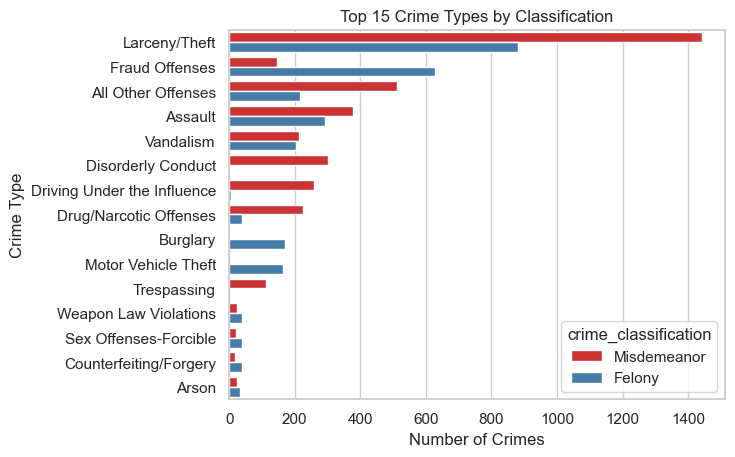

In [45]:
import pandas as pd
import seaborn as sns

df = pd.read_csv("cleaned_data_feature_engineered_v1.csv")

sns.set_theme(style = "whitegrid")

top_types = df["crime_type"].value_counts().head(15).index

p = sns.countplot(
    data = df[df["crime_type"].isin(top_types)], 
    y = "crime_type", 
    hue = "crime_classification", 
    order = top_types, 
    palette = "Set1" 
)

p.set(
    xlabel = "Number of Crimes",
    ylabel = "Crime Type",
    title = "Top 15 Crime Types by Classification"
)

# create countplot showing number of crimes from top 15 crime types

[(-121.78762817382812, -121.68870277404797),
 (38.53871154785156, 38.57039),
 Text(0.5, 0, 'Longitude'),
 Text(0, 0.5, 'Latitude'),
 Text(0.5, 1.0, 'Crime Density Heatmap')]

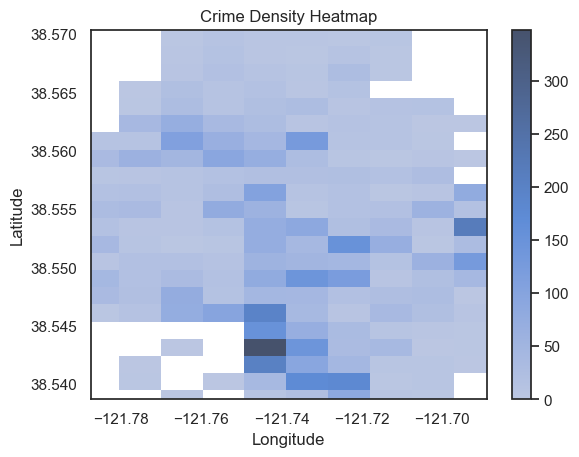

In [46]:
import pandas as pd
import seaborn as sns

df = pd.read_csv("cleaned_data_feature_engineered_v1.csv")

# Remove coordinate outliers by focusing on the main parts of the data. Allows for a more focused visualization area
x_min, x_max = df["x_coord"].quantile([0.01, 0.99])
y_min, y_max = df["y_coord"].quantile([0.01, 0.99])

sns.set_theme(style="white")

# create histogram heatmap showing crime density using longitude(x) and latitude(y)
plot = sns.histplot(
    data = df,
    x = "x_coord", 
    y = "y_coord", 
    bins = 100,    
    cbar = True    
)

# limits axes to the central crime clusters
plot.set(
    xlim = (x_min, x_max), # zooms into main crime area horizontally
    ylim = (y_min, y_max), # zooms into main crime area vertically
    xlabel = "Longitude",
    ylabel = "Latitude",
    title = "Crime Density Heatmap"
)


In [48]:
# original logistic regression model

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [35]:
import pandas as pd
import numpy as np

df = pd.read_csv("cleaned_data_feature_engineered_v1.csv")

# convert variables to numeric, Misdemeanor = 0 and Felony = 1
df["crime_classification"] = df["crime_classification"].map({"Misdemeanor": 0, "Felony": 1})

# convert catergorical variables into binary variables 
df = pd.get_dummies(df, columns = ["crime_type", "incident_timing"])

# create feature matrix, removing columns that are identifiers or not useful
X = df.drop(columns = [
    "crime_classification", "case_number", "report_date",
    "occurrence_date", "occurrence_time", "incident_number",
    "place", "city", "disposition", "beat", "block_number",
    "street", "coord_check", "upload_date", "offense_description"
]).values

# create target vector
y = df["crime_classification"].values

# makes sure all values are numbers
X = X.astype(float)
y = y.astype(float)

# Reshape into 2D even if only 1 feature
if X.ndim == 1:
    X = X.reshape(-1, 1)

# Add intercept column
X = np.c_[np.ones(X.shape[0], dtype=float), X]

# Sigmoid function, converts linear predictions into provabilities between 0 and 1
def sigmoid(z):
    z = np.array(z, dtype = float)
    return 1 / (1 + np.exp(-z))

# Initialize model weights to zero, 1  weight per feature
weights = np.zeros(X.shape[1], dtype=float)

# set hyperparameters, learning_rate controls step size, iterations control training length
learning_rate = 0.01
iterations = 2000

# Gradient descent, updates weights to minimize loss
for i in range(iterations):
    z = np.dot(X, weights) # linear combination of features and weights
    z = np.atleast_1d(z)   # ensures variable is at least 1 dimensional array
    predictions = sigmoid(z) # convert to probabilities
    gradient = np.dot(X.T, (predictions - y)) / len(y) # compute gradient of loss function
    weights -= learning_rate * gradient # update weight

# Make prediction probabilities
probabilities = sigmoid(np.dot(X, weights))

# convert probabilities to class labels, Probability >= 0.5 -> felony, < 0.5 -> misdemeanor
predictions = (probabilities >= 0.5).astype(int)

# Model performance 
accuracy = np.mean(predictions == y)


print("Model Accuracy:", accuracy)
print("Model Weights:", weights)

Model Accuracy: 0.43382798304058146
Model Weights: [ 0.00392668 -0.4750585   0.15437527 -0.3013072   0.02798953  0.00211199
  0.2893066   0.04482986 -0.03285358 -0.38817941 -0.32973223 -0.23071594
  0.01186883  0.00724926  0.00422392  0.86862477  0.00685185  0.01318546
 -0.36665583 -0.01576359  0.27831785  0.03334023  0.00171171  0.06334891
  0.04049206  0.00382917  0.0159751  -0.14949219  0.06843203  0.03693749
 -0.05920807  0.06313475]


In [7]:
feature_names = ["intercept"] + list(df.drop(columns=[
    "crime_classification",
    "case_number",
    "report_date",
    "occurrence_date",
    "occurrence_time",
    "incident_number",
    "place",
    "city",
    "disposition",
    "beat",
    "block_number",
    "street",
    "coord_check",
    "upload_date",
    "offense_description"
]).columns)

for name, weight in zip(feature_names, weights):
    print(name, weight)

intercept 0.003926676152137276
x_coord -0.475058497871504
y_coord 0.15437527432198256
crime_type_All Other Offenses -0.30130720452327664
crime_type_Arson 0.027989534292880057
crime_type_Assault 0.0021119887350816258
crime_type_Burglary 0.2893066014765165
crime_type_Counterfeiting/Forgery 0.0448298622408541
crime_type_Curfew/Loitering/Vagrancy -0.03285358317001965
crime_type_Disorderly Conduct -0.38817941121602006
crime_type_Driving Under the Influence -0.3297322297555304
crime_type_Drug/Narcotic Offenses -0.2307159412569077
crime_type_Embezzlement 0.011868834810118236
crime_type_Extortion/Blackmail 0.00724926311410146
crime_type_Family Offenses Non Violent 0.004223922479960934
crime_type_Fraud Offenses 0.8686247684647741
crime_type_Homicide 0.006851854928448911
crime_type_Kidnapping/Abduction 0.013185459436422436
crime_type_Larceny/Theft -0.36665582965991966
crime_type_Liquor Law Violation -0.015763591495158675
crime_type_Motor Vehicle Theft 0.27831784831572653
crime_type_Pornography/O

In [ ]:
# improved logistic regression model

In [49]:
import pandas as pd
import numpy as np


df = pd.read_csv("cleaned_data_feature_engineered_v1.csv")

# Convert target variable to binary; 0 = Misdemeanor, 1 = Felony
df["crime_classification"] = df["crime_classification"].map({
    "Misdemeanor": 0,
    "Felony": 1
})

# Convert date and time columns to date time format
df["occurrence_date"] = pd.to_datetime(df["occurrence_date"])
df["occurrence_time"] = pd.to_datetime(df["occurrence_time"])

# time-based predictors, hour of the day (0–23)
df["hour"] = df["occurrence_time"].dt.hour

# Day of the week 
df["day_of_week"] = df["occurrence_date"].dt.dayofweek

# Create Academic vs Summer season
month = df["occurrence_date"].dt.month

df["season"] = np.where(
    month.isin([6,7,8]),
    "Summer",
    "Academic"
)

# categorical variables
df = pd.get_dummies(df, columns=[
    "crime_type",
    "incident_timing",
    "season"
])

# Remove non-predictive identifier columns
X = df.drop(columns=[
    "crime_classification",
    "case_number",
    "report_date",
    "occurrence_date",
    "occurrence_time",
    "incident_number",
    "place",
    "city",
    "disposition",
    "beat",
    "block_number",
    "street",
    "coord_check",
    "upload_date",
    "offense_description"
]).values

# Target variable
y = df["crime_classification"].values

# Ensure numeric data types
X = X.astype(float)
y = y.astype(float)

# Add intercept column 
X = np.c_[np.ones(X.shape[0]), X]

# Sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Initialize model weights
weights = np.zeros(X.shape[1])

# Hyperparameters
learning_rate = 0.01
iterations = 2000

# Train model using gradient descent
for i in range(iterations):
    z = np.dot(X, weights)
    predictions = sigmoid(z)
    gradient = np.dot(X.T, (predictions - y)) / len(y)
    weights -= learning_rate * gradient

# Generate predictions
probabilities = sigmoid(np.dot(X, weights))

# Convert probabilities to classes
predictions = (probabilities >= 0.5).astype(int)

# model accuracy
accuracy = np.mean(predictions == y)

print("Model Accuracy:", accuracy)
print("Number of Features:", X.shape[1])
print("Model Weights:", weights)

/var/folders/p8/r48cp0ws315496q0p77hrwd00000gn/T/ipykernel_35836/2400025514.py:15: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["occurrence_time"] = pd.to_datetime(df["occurrence_time"])


Model Accuracy: 0.5169594185342217
Number of Features: 36
Model Weights: [ 6.76699131e-04 -7.91527624e-02  2.90426088e-02 -5.01067799e-01
 -8.61284849e-01 -2.93247144e-01  2.68139644e-02  5.90336198e-03
  2.82172470e-01  4.14653904e-02 -3.24262241e-02 -3.81142646e-01
 -3.39027468e-01 -2.28636426e-01  1.04709501e-02  7.22237469e-03
  4.56287917e-03  8.49842041e-01  6.92337246e-03  1.40060733e-02
 -3.46540334e-01 -1.53306622e-02  2.77945628e-01  2.94534482e-02
  1.81341490e-03  6.37894955e-02  3.89224781e-02  3.59407893e-03
  1.59565044e-02 -1.48222704e-01  6.59931105e-02  3.83992729e-02
 -6.54187798e-02  6.60954789e-02 -9.66527501e-02  9.73294492e-02]


In [51]:
feature_names = df.drop(columns=[
    "crime_classification",
    "case_number",
    "report_date",
    "occurrence_date",
    "occurrence_time",
    "incident_number",
    "place",
    "city",
    "disposition",
    "beat",
    "block_number",
    "street",
    "coord_check",
    "upload_date",
    "offense_description"
]).columns

coef_table = coef_table.sort_values(by="Coefficient", ascending=False)

print(coef_table)

                                    Feature  Coefficient
17                crime_type_Fraud Offenses     0.849842
8                       crime_type_Burglary     0.282172
22           crime_type_Motor Vehicle Theft     0.277946
35                            season_Summer     0.097329
33                   incident_timing_Summer     0.066095
30                     crime_type_Vandalism     0.065993
25                       crime_type_Robbery     0.063789
9         crime_type_Counterfeiting/Forgery     0.041465
26         crime_type_Sex Offenses-Forcible     0.038922
31         crime_type_Weapon Law Violations     0.038399
23  crime_type_Pornography/Obscene Material     0.029453
2                                   y_coord     0.029043
6                          crime_type_Arson     0.026814
28               crime_type_Stolen Property     0.015957
19          crime_type_Kidnapping/Abduction     0.014006
14                  crime_type_Embezzlement     0.010471
15           crime_type_Extorti